# Assignment 3
### Due 9/23. Do four of five.

1.
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import read_csv

In [7]:
nhanes = read_csv("nhanes_meta_17_18.csv")
nhanes

,VariableNameLong,Variable,Type,Format,Informat,Label,Source,VariableName,SASLabel,EnglishText,Target,VariableNameLong_variable_df,Source_variable_df,EnglishInstructions,HardEdits,Recoded,CustomRecoding,nNonNA
0,GeneralHealthCondition,HSD010,Numeric,NaN,NaN,General health condition,HSQ,HSD010,General health condition,Next I have some general questions about {your...,Both males and females 12 YEARS -\n\n\t\t\t15...,GeneralHealthCondition,HSQ,NaN,NaN,True,NaN,5964.0
1,EverBreastfedOrFedBreastmilk,DBQ010,Numeric,NaN,NaN,Ever breastfed or fed breastmilk,DBQ,DBQ010,Ever breastfed or fed breastmilk,Now I'm going to ask you some general question...,Both males and females 0 YEARS -\n\n\t\t\t6 Y...,EverBreastfedOrFedBreastmilk,DBQ,NaN,NaN,True,YesNo,1069.0
2,AgeStoppedBreastfeedingdays,DBD030,Numeric,NaN,NaN,Age stopped breastfeeding(days),DBQ,DBD030,Age stopped breastfeeding(days),How old was {SP} when {he/she} completely stop...,Both males and females 0 YEARS -\n\n\t\t\t6 Y...,AgeStoppedBreastfeedingdays,DBQ,NaN,NaN,False,NaN,862.0
3,AgeFirstFedFormuladays,DBD041,Numeric,NaN,NaN,Age first fed formula(days),DBQ,DBD041,Age first fed formula(days),How old was {SP} when {he/she} was first fed f...,Both males and females 0 YEARS -\n\n\t\t\t6 Y...,AgeFirstFedFormuladays,DBQ,NaN,NaN,False,NaN,1077.0
4,AgeStoppedReceivingFormuladays,DBD050,Numeric,NaN,NaN,Age stopped receiving formula(days),DBQ,DBD050,Age stopped receiving formula(days),How old was {SP} when {he/she} completely stop...,Both males and females 0 YEARS -\n\n\t\t\t6 Y...,AgeStoppedReceivingFormuladays,DBQ,NaN,NaN,False,NaN,891.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,UnitOfMeasureDayweekmonthyear_2_SMQ,SMQ852U,Numeric,NaN,NaN,Unit of measure (day/week/month/year),SMQ,SMQ852U,Unit of measure (day/week/month/year),"The last time {you/SP} tried to quit, how long...",Both males and females 18 YEARS -\n\n\t\t\t15...,UnitOfMeasureDayweekmonthyear,SMQ,ENTER UNIT,NaN,True,NaN,496.0
193,CurrentSelfreportedHeightInches,WHD010,Numeric,NaN,NaN,Current self-reported height (inches),WHQ,WHD010,Current self-reported height (inches),These next questions ask about {your/SP's} hei...,Both males and females 16 YEARS -\n\n\t\t\t15...,CurrentSelfreportedHeightInches,WHQ,ENTER HEIGHT IN FEET AND INCHES OR METERS AND ...,NaN,False,NaN,5776.0
194,CurrentSelfreportedWeightPounds,WHD020,Numeric,NaN,NaN,Current self-reported weight (pounds),WHQ,WHD020,Current self-reported weight (pounds),How much {do you/does SP} weigh without clothe...,Both males and females 16 YEARS -\n\n\t\t\t15...,CurrentSelfreportedWeightPounds,WHQ,"RECORD CURRENT WEIGHT. IF PREGNANT, ASK FOR WE...",NaN,False,NaN,5828.0
195,TriedToLoseWeightInPastYear,WHQ070,Numeric,NaN,NaN,Tried to lose weight in past year,WHQ,WHQ070,Tried to lose weight in past year,"During the past 12 months, {have you/has SP} t...",Both males and females 16 YEARS -\n\n\t\t\t15...,TriedToLoseWeightInPastYear,WHQ,NaN,NaN,True,YesNo,5087.0


In [20]:
# create list of categorical variable types from nhanes
nhane_cat_list = nhanes[nhanes['Type'] != 'Numeric']
len(nhane_cat_list)

2

In [10]:
nhanes_data = read_csv("nhanes_data_17_18.csv")
nhanes_data

/tmp/ipython-input-1547042560.py:1: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  nhanes_data = read_csv("nhanes_data_17_18.csv")


,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8361,102952.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.0,0.0,Never
8362,102953.0,Fair or,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,65.0,218.0,0.0,Never
8363,102954.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,66.0,150.0,0.0,Never
8364,102955.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# count nan nhanes all data shown
useful = nhanes_data.isna().sum().sort_values(ascending=True).head(50)
useful

,0
SEQN,0
TotalNumberOfPeopleInTheHousehold,0
OfChildren617YearsOldInHh,0
OfChildren5YearsOrYoungerInHh,0
Gender,0
AgeInYearsAtScreening,0
RacehispanicOriginWNhAsian,0
OfAdults60YearsOrOlderInHh,0
TotalNumberOfPeopleInTheFamily,0
RacehispanicOrigin,0


In [70]:
targetted = nhanes_data[["RacehispanicOriginWNhAsian","CoveredByHealthInsurance"]]
targetted


,RacehispanicOriginWNhAsian,CoveredByHealthInsurance
0,Non-Hispanic Asian,1.0
1,Non-Hispanic White,1.0
2,Non-Hispanic Black,1.0
3,Non-Hispanic Asian,1.0
4,Other Race - Including Multi-Racial,1.0
...,...,...
8361,Non-Hispanic Asian,1.0
8362,Mexican American,1.0
8363,Non-Hispanic Black,1.0
8364,Non-Hispanic Black,1.0


In [71]:
na_cols = targetted.columns[targetted.isna().any()].tolist()
print(na_cols)
rows_with_any_nan = targetted[targetted.isna().any(axis=1)]
rows_with_any_nan

['CoveredByHealthInsurance']


,RacehispanicOriginWNhAsian,CoveredByHealthInsurance
25,Non-Hispanic Black,NaN
185,Mexican American,NaN
253,Non-Hispanic Asian,NaN
1638,Non-Hispanic Black,NaN
1685,Other Race - Including Multi-Racial,NaN
1774,Non-Hispanic Black,NaN
2928,Non-Hispanic Black,NaN
3019,Mexican American,NaN
3267,Mexican American,NaN
3435,Non-Hispanic Black,NaN


In [72]:
print(targetted['RacehispanicOriginWNhAsian'].unique())

['Non-Hispanic Asian' 'Non-Hispanic White' 'Non-Hispanic Black'
 'Other Race - Including Multi-Racial' 'Mexican American' 'Other Hispanic']


In [77]:
ct_missing = pd.crosstab(
    targetted['RacehispanicOriginWNhAsian'].fillna('Missing'),
    targetted['CoveredByHealthInsurance'].fillna('Missing')
)
print(ct_missing)
print("")

ct_all_pct = pd.crosstab(targetted['RacehispanicOriginWNhAsian'], targetted['CoveredByHealthInsurance'], normalize='index')
print(ct_all_pct)

CoveredByHealthInsurance             0.0   1.0  Missing
RacehispanicOriginWNhAsian                             
Mexican American                     260   961        8
Non-Hispanic Asian                    85   996        2
Non-Hispanic Black                   230  1712        7
Non-Hispanic White                   235  2557        0
Other Hispanic                       132   605        1
Other Race - Including Multi-Racial   53   520        2

CoveredByHealthInsurance                  0.0       1.0
RacehispanicOriginWNhAsian                             
Mexican American                     0.212940  0.787060
Non-Hispanic Asian                   0.078631  0.921369
Non-Hispanic Black                   0.118435  0.881565
Non-Hispanic White                   0.084169  0.915831
Other Hispanic                       0.179104  0.820896
Other Race - Including Multi-Racial  0.092496  0.907504


# 1.d After producing the contingency table on a whim, mainly based on the number of NaN there were for a column and a joke of curiosity, there is an apparent pattern/trend between ethnicity and health insurance converage. Asian, White, Mixed, Black, and Hispanic have a descending level of coverage in that order. I am very interested to see more insights.


2.
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

In [80]:
nhanes_2 = read_csv("nhanes_data_17_18.csv")
useful = nhanes_data.isna().sum().sort_values(ascending=True).head(50)
print(useful)



SEQN                                          0
TotalNumberOfPeopleInTheHousehold             0
OfChildren617YearsOldInHh                     0
OfChildren5YearsOrYoungerInHh                 0
Gender                                        0
AgeInYearsAtScreening                         0
RacehispanicOriginWNhAsian                    0
OfAdults60YearsOrOlderInHh                    0
TotalNumberOfPeopleInTheFamily                0
RacehispanicOrigin                            0
HaveSeriousDifficultySeeing                   1
Past30DayMilkProductConsumption               1
TakingInsulinNow                              1
HaveSeriousDifficultyHearing                  1
DoctorToldYouHaveDiabetes                     4
EverBeenToldYouHaveAsthma                     7
CoveredByHealthInsurance                     20
OfMealsNotHomePrepared                       30
OfReadytoeatFoodsInPast30Days                32
OfFrozenMealspizzaInPast30Days               34
WeightKg                                

/tmp/ipython-input-3646788199.py:1: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  nhanes_2 = read_csv("nhanes_data_17_18.csv")


In [84]:
# BloodMercuryTotalUgl
print(nhanes_2['BloodMercuryTotalUgl'].unique())

[  nan  0.47  1.07 10.64  0.2  15.23  0.41  0.53  1.24  2.13  4.41  0.36
  2.28  0.29  0.73  0.48  1.5   0.44  1.51  0.98  2.14  0.5   0.37  5.05
  0.35  0.84  1.53  2.92  1.43  0.57  0.97  1.13  2.84  0.68  0.51  0.7
  0.45  0.77  0.66  1.4   0.59  0.56  1.41  1.84  0.61  0.31  2.38  0.33
  1.82  1.21  0.99  0.75  1.28  1.05  1.11  0.96  1.02  1.42  1.44  3.62
  0.54  4.38  4.55  5.07  4.66  1.67  1.12  6.25  1.9   1.66  0.34  1.38
  0.32  1.75  1.34  0.58  1.52  0.43  3.15  1.7   0.82  2.43  0.83  1.8
  0.93  3.04  0.28  0.49  2.89  0.3   1.56  0.39  1.32  2.72  0.6   1.87
  0.92  2.62  0.64  2.88  0.74  0.94  0.88  9.76  0.4   5.02  1.89  0.69
  3.4   5.93  1.2   1.95  3.38  2.45  0.72  1.08  1.17  9.95  3.27  5.58
  0.67  0.65  0.76  6.81  4.92  0.46  1.88  7.85  2.09  1.19  0.91  1.57
  1.78  0.62  0.63  4.63  3.8   1.22  2.1   1.58  2.63  1.61  4.13  0.42
  2.08  1.31  0.85  4.22  6.31  1.79  3.34  3.44  0.87  2.65  0.55  0.78
  2.58  0.71  1.59  0.86  1.18  2.48  3.12  1.73  2.2

In [104]:
tar2 = nhanes_2[["BloodMercuryTotalUgl","RacehispanicOriginWNhAsian"]]
tar2 = tar2.rename(columns={"BloodMercuryTotalUgl": "Mercury", "RacehispanicOriginWNhAsian": "Race"})
print(tar2)
na_cols_2 = tar2.columns[tar2.isna().any()].tolist()
print(na_cols_2)
rows_with_any_nan_2 = tar2[tar2.isna().any(axis=1)]
rows_with_any_nan_2

      Mercury                                 Race
0         NaN                   Non-Hispanic Asian
1        0.47                   Non-Hispanic White
2        1.07                   Non-Hispanic Black
3       10.64                   Non-Hispanic Asian
4        0.20  Other Race - Including Multi-Racial
...       ...                                  ...
8361     0.65                   Non-Hispanic Asian
8362     0.62                     Mexican American
8363     2.08                   Non-Hispanic Black
8364     0.20                   Non-Hispanic Black
8365     0.83                   Non-Hispanic White

[8366 rows x 2 columns]
['Mercury']


,Mercury,Race
0,NaN,Non-Hispanic Asian
21,NaN,Non-Hispanic White
28,NaN,Non-Hispanic White
35,NaN,Non-Hispanic Black
40,NaN,Non-Hispanic Asian
...,...,...
8323,NaN,Non-Hispanic Black
8337,NaN,Non-Hispanic Black
8347,NaN,Non-Hispanic White
8348,NaN,Other Race - Including Multi-Racial


In [105]:
count_tbl = (tar2["Race"]
             .value_counts(dropna=False)
             .rename_axis("Race")
             .to_frame("n")
             .assign(prop=lambda t: t["n"] / t["n"].sum()))
print("\n[Counts by group]")
print(count_tbl)


[Counts by group]
                                        n      prop
Race                                               
Non-Hispanic White                   2792  0.333732
Non-Hispanic Black                   1949  0.232967
Mexican American                     1229  0.146904
Non-Hispanic Asian                   1083  0.129453
Other Hispanic                        738  0.088214
Other Race - Including Multi-Racial   575  0.068731


In [106]:
summary_tbl = (tar2.groupby("Race", observed=True)["Mercury"]
               .agg(n="count", mean="mean", std="std",
                    min="min", q25=lambda s: s.quantile(0.25),
                    median="median", q75=lambda s: s.quantile(0.75),
                    max="max", iqr=lambda s: s.quantile(0.75)-s.quantile(0.25))
               )
print("\nSummary of BloodMercuryTotalUgl by RacehispanicOriginWNhAsian")
print(summary_tbl)


Summary of BloodMercuryTotalUgl by RacehispanicOriginWNhAsian
                                        n      mean       std  min     q25  \
Race                                                                         
Mexican American                     1134  0.858748  1.644925  0.2  0.2000   
Non-Hispanic Asian                    946  2.789450  4.879374  0.2  0.3925   
Non-Hispanic Black                   1708  1.054930  1.594898  0.2  0.3000   
Non-Hispanic White                   2536  0.792319  1.128300  0.2  0.2000   
Other Hispanic                        682  1.099604  1.637662  0.2  0.3500   
Other Race - Including Multi-Racial   507  0.811400  1.174610  0.2  0.2000   

                                     median     q75    max     iqr  
Race                                                                
Mexican American                      0.425  0.8400  20.85  0.6400  
Non-Hispanic Asian                    1.260  3.2425  63.64  2.8500  
Non-Hispanic Black                  

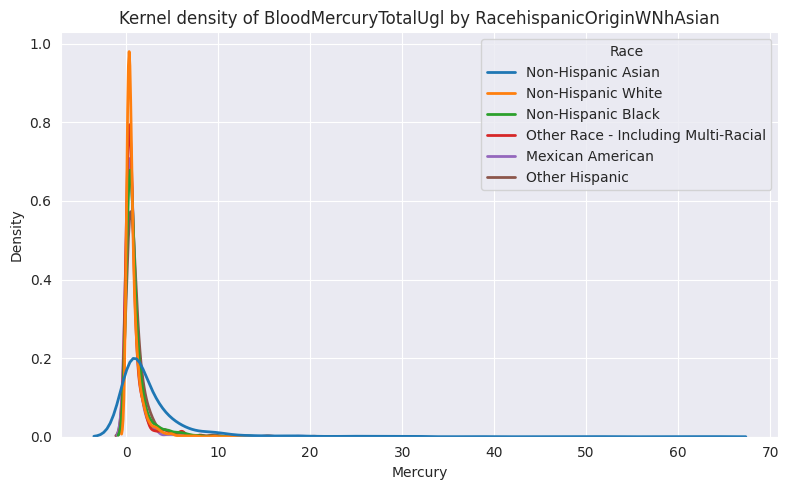

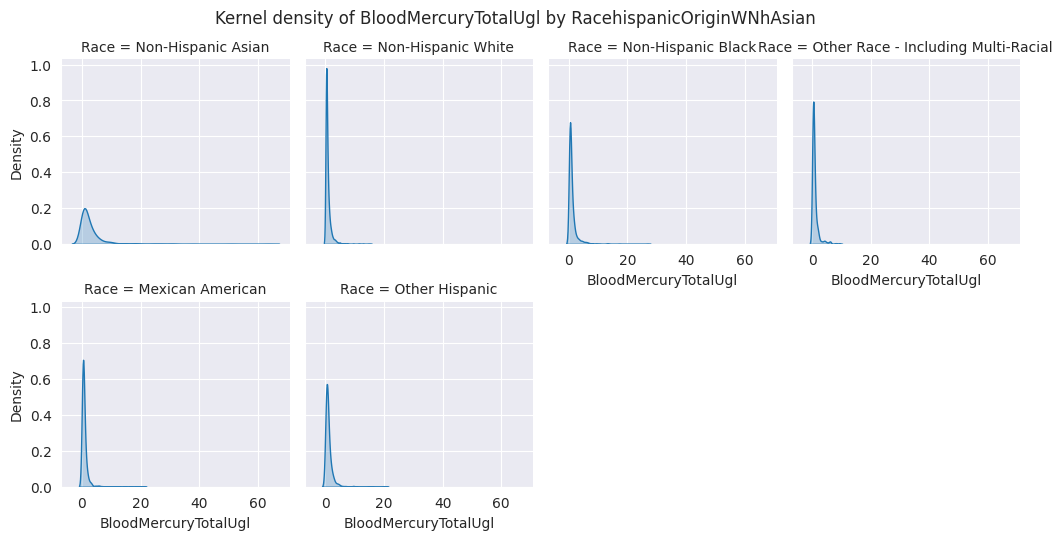

In [108]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=tar2, x="Mercury", hue="Race", common_norm=False, bw_adjust=1.0, linewidth=2)
plt.title(f"Kernel density of BloodMercuryTotalUgl by RacehispanicOriginWNhAsian")
plt.xlabel("Mercury"); plt.ylabel("Density")
plt.tight_layout()
plt.show()

g = sns.displot(
    data=tar2, x="Mercury", col="Race", col_wrap=4, kind="kde", fill=True,
    common_norm=False, bw_adjust=1.0, height=2.6, facet_kws={"sharex": True, "sharey": True}
)
g.set_axis_labels("BloodMercuryTotalUgl", "Density")
g.fig.suptitle(f"Kernel density of BloodMercuryTotalUgl by RacehispanicOriginWNhAsian", y=1.03)
plt.show()

# 2.d There appears to be a wide variation between races, especially between the asians and whites in terms of the distribution of values for mercury in bloodstreams of individuals. However, Hispanic, Mexican, Black, and mixed are roughly within the same range of the distribution. It is interesting to see the difference and I wonder if it has to do with cultural preferences.

3.
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

- $$
MSE(\hat{y}(z)) =
$$
- $$
\dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
- $$  μ = \hat{y}(z) $$
- $$ w_i(z) = \frac{1}{h}k(\frac{z-x_i}{h}) \ge 0 $$
- $$ \frac{∂}{∂μ}MSE(μ;z) = $$
- $$ \frac{∂}{∂μ} \frac{1}{N} \sum_{i=1}^N w_i(z)(y_i-μ)^2 = 0$$
- $$ = \frac{2}{N} \sum_{i=1}^N w_i(z)(μ-y_i) = 0$$
- $$ = \frac{2}{N} (\sum_{i=1}^N w_i(z)μ - \sum_{i=1}^Nw_i(z)y_i) = 0$$
- $$ \sum_{i=1}^N w_i(z)μ - \sum_{i=1}^Nw_i(z)y_i = 0 $$
- $$ μ = \hat{y}(z) = \frac{\sum_{i=1}^Nw_i(z)y_i}{\sum_{i=1}^N w_i(z)} $$
- $$ = \frac{\sum_{i=1}^N\frac{1}{h}k(\frac{z-x_i}{h})y_i}{\sum_{i=1}^N \frac{1}{h}k(\frac{z-x_i}{h})} $$


4.
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

# I used chat for 4 since this is the one I am "not" doing

In [109]:
import numpy as np
from dataclasses import dataclass
from typing import Callable, Iterable, Optional, Union

ArrayLike = Union[np.ndarray, Iterable[float]]

# ----------------------------
# Silverman plug-in bandwidth
# ----------------------------
def silverman_bandwidth(x: ArrayLike, robust: bool = True) -> float:
    """
    Silverman's 'rule-of-thumb' bandwidth for univariate X.

    robust=True uses 0.9 * min(std, IQR/1.34) * n^(-1/5)
    robust=False uses 1.06 * std * n^(-1/5)
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    if n < 2:
        return 1.0  # arbitrary fallback when we can't estimate scale

    s = np.std(x, ddof=1)
    q25, q75 = np.percentile(x, [25, 75])
    iqr = q75 - q25

    if robust:
        scale = min(s, iqr / 1.34) if iqr > 0 else s
        c = 0.9
    else:
        scale = s
        c = 1.06

    # Degenerate case: all X identical → scale=0. Return small nonzero h.
    if not np.isfinite(scale) or scale == 0:
        # choose a tiny scale relative to X range; if range=0, use 1.0
        x_range = np.max(x) - np.min(x)
        scale = x_range if x_range > 0 else 1.0
        return c * scale * n ** (-1/5) * 1e-3

    return c * scale * n ** (-1/5)

# ------------
# Kernels
# ------------
def gaussian_kernel(u: np.ndarray) -> np.ndarray:
    """Standard normal pdf kernel."""
    return np.exp(-0.5 * u * u) / np.sqrt(2.0 * np.pi)

KERNELS = {
    "gaussian": gaussian_kernel,
    # You can add others (epanechnikov, triweight, etc.) if you like.
}

# ----------------------------------------------------------
# Nadaraya–Watson (Local Constant Least Squares) Estimator
# ----------------------------------------------------------
@dataclass
class NadarayaWatson:
    kernel: Union[str, Callable[[np.ndarray], np.ndarray]] = "gaussian"
    bandwidth: Optional[float] = None           # if None, use Silverman
    silverman_robust: bool = True               # controls Silverman's rule
    bandwidth_scale: float = 1.0                # multiply h by this (manual tuning)
    fallback: str = "mean"                      # when denom ~ 0: "mean" or "nan"

    def fit(
        self,
        X: ArrayLike,
        y: ArrayLike,
        sample_weight: Optional[ArrayLike] = None,
    ):
        X = np.asarray(X, dtype=float).reshape(-1)
        y = np.asarray(y, dtype=float).reshape(-1)
        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must have the same length.")

        # Keep only finite pairs
        mask = np.isfinite(X) & np.isfinite(y)
        self.X_ = X[mask]
        self.y_ = y[mask]

        if self.X_.size == 0:
            raise ValueError("No valid (finite) observations in X/y.")

        if sample_weight is not None:
            w = np.asarray(sample_weight, dtype=float).reshape(-1)[mask]
            # normalize weights to sum to n for stability (optional)
            w = np.clip(w, 0.0, np.inf)
            if w.sum() == 0:
                self.w_ = None
            else:
                self.w_ = w * (self.X_.size / w.sum())
        else:
            self.w_ = None

        # Bandwidth
        if self.bandwidth is None:
            h = silverman_bandwidth(self.X_, robust=self.silverman_robust)
        else:
            h = float(self.bandwidth)
        self.h_ = max(np.finfo(float).eps, h * float(self.bandwidth_scale))

        # Kernel
        if isinstance(self.kernel, str):
            try:
                self.kernel_ = KERNELS[self.kernel.lower()]
            except KeyError:
                raise ValueError(f"Unknown kernel '{self.kernel}'.")
        else:
            self.kernel_ = self.kernel

        # Global mean (used as fallback if needed)
        self.global_mean_ = float(np.average(self.y_, weights=self.w_) if self.w_ is not None else self.y_.mean())
        return self

    def predict(self, Z: ArrayLike) -> np.ndarray:
        if not hasattr(self, "X_"):
            raise RuntimeError("Call fit(X, y) before predict().")

        Z = np.asarray(Z, dtype=float).reshape(-1)
        h = self.h_
        K = self.kernel_

        # Compute kernel weights for each query point: shape (m, n)
        u = (Z[:, None] - self.X_[None, :]) / h
        W = K(u)
        if self.w_ is not None:
            W = W * self.w_[None, :]

        num = W @ self.y_
        den = W.sum(axis=1)

        # Handle near-zero denominators
        near_zero = den <= np.finfo(float).tiny
        yhat = np.empty_like(Z, dtype=float)
        yhat[~near_zero] = num[~near_zero] / den[~near_zero]
        if np.any(near_zero):
            if self.fallback == "mean":
                yhat[near_zero] = self.global_mean_
            elif self.fallback == "nan":
                yhat[near_zero] = np.nan
            else:
                raise ValueError("fallback must be 'mean' or 'nan'.")
        return yhat

# --------------------
# Functional helpers
# --------------------
def nw_predict(
    z: ArrayLike,
    x: ArrayLike,
    y: ArrayLike,
    h: Optional[float] = None,
    kernel: Union[str, Callable[[np.ndarray], np.ndarray]] = "gaussian",
    silverman_robust: bool = True,
    bandwidth_scale: float = 1.0,
    sample_weight: Optional[ArrayLike] = None,
    fallback: str = "mean",
) -> np.ndarray:
    """
    One-shot Nadaraya–Watson prediction.
    If h is None, use Silverman's bandwidth computed from x.
    """
    model = NadarayaWatson(
        kernel=kernel,
        bandwidth=h,
        silverman_robust=silverman_robust,
        bandwidth_scale=bandwidth_scale,
        fallback=fallback,
    ).fit(x, y, sample_weight=sample_weight)
    return model.predict(z)


In [113]:
# Toy data
rng = np.random.default_rng(0)
x = np.linspace(-3, 3, 300)
y_true = np.sin(x) + 0.2 * x
y = y_true + rng.normal(0, 0.3, size=x.size)

# Fit/predict with the class
nw = NadarayaWatson(bandwidth=None)  # None → use Silverman plug-in on X
nw.fit(x, y)
z = np.linspace(-3, 3, 200)
y_hat = nw.predict(z)

# Or with the one-shot function
y_hat2 = nw_predict(z, x, y)  # same as above


5.
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome

In [115]:
nhanes_5 = read_csv("nhanes_data_17_18.csv")
useful = nhanes_5.isna().sum().sort_values(ascending=True).head(50)
print(useful)

SEQN                                          0
TotalNumberOfPeopleInTheHousehold             0
OfChildren617YearsOldInHh                     0
OfChildren5YearsOrYoungerInHh                 0
Gender                                        0
AgeInYearsAtScreening                         0
RacehispanicOriginWNhAsian                    0
OfAdults60YearsOrOlderInHh                    0
TotalNumberOfPeopleInTheFamily                0
RacehispanicOrigin                            0
HaveSeriousDifficultySeeing                   1
Past30DayMilkProductConsumption               1
TakingInsulinNow                              1
HaveSeriousDifficultyHearing                  1
DoctorToldYouHaveDiabetes                     4
EverBeenToldYouHaveAsthma                     7
CoveredByHealthInsurance                     20
OfMealsNotHomePrepared                       30
OfReadytoeatFoodsInPast30Days                32
OfFrozenMealspizzaInPast30Days               34
WeightKg                                

/tmp/ipython-input-68632101.py:1: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  nhanes_5 = read_csv("nhanes_data_17_18.csv")


441
49


Text(0, 0.5, 'Heart Rate')

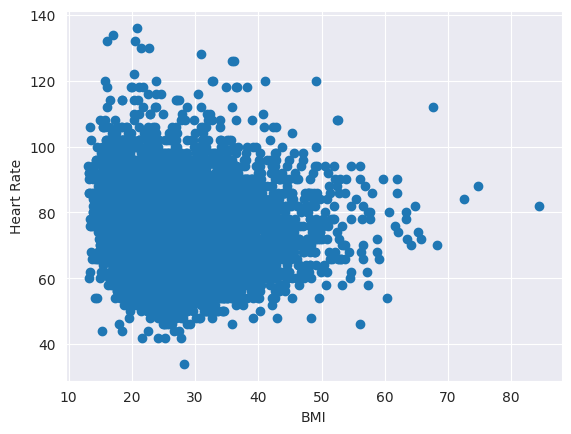

In [142]:
x = nhanes_5['BodyMassIndexKgm2']
y = nhanes_5['60SecPulse30SecPulse2']

print(len(x.unique()))
print(len(y.unique()))

plt.scatter(x=x, y=y)
plt.xlabel("BMI")
plt.ylabel("Heart Rate")

In [153]:
xy = xy.dropna()
x = xy['BodyMassIndexKgm2']
y = xy['60SecPulse30SecPulse2']
print(xy)
X = sm.add_constant(xy['BodyMassIndexKgm2']) # intercept + x
ols = sm.OLS(y, X).fit()
print(ols.summary())

      BodyMassIndexKgm2  60SecPulse30SecPulse2
2                  31.7                   52.0
3                  21.5                   82.0
4                  18.1                  100.0
5                  23.7                   68.0
6                  38.9                   74.0
...                 ...                    ...
8361               20.0                   68.0
8362               35.8                   78.0
8363               26.1                   78.0
8364               45.6                   74.0
8365               36.1                   76.0

[6662 rows x 2 columns]
                              OLS Regression Results                             
Dep. Variable:     60SecPulse30SecPulse2   R-squared:                       0.004
Model:                               OLS   Adj. R-squared:                  0.004
Method:                    Least Squares   F-statistic:                     27.19
Date:                   Mon, 22 Sep 2025   Prob (F-statistic):           1.90e-07
T

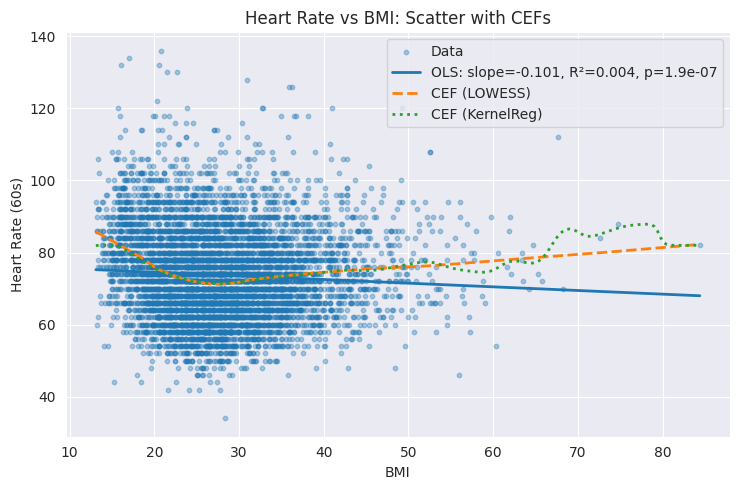

In [149]:
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.nonparametric.kernel_regression import KernelReg

# --- data ---
xy = nhanes_5[['BodyMassIndexKgm2', '60SecPulse30SecPulse2']].dropna()
x = xy['BodyMassIndexKgm2'].values
y = xy['60SecPulse30SecPulse2'].values

# --- OLS (parametric CEF) ---
X = sm.add_constant(x)
ols = sm.OLS(y, X).fit()
b0, b1 = ols.params
r2 = ols.rsquared
p_slope = ols.pvalues[1]

# --- Nonparametric CEFs ---
# (a) LOWESS
low = lowess(y, x, frac=0.3, it=0, return_sorted=True)  # (x_sorted, yhat)

# (b) Kernel regression (Nadaraya–Watson, local constant)
kr = KernelReg(endog=y, exog=x, var_type='c', reg_type='lc')  # Silverman h inside
grid = np.linspace(x.min(), x.max(), 200)
mhat, _ = kr.fit(grid)

# --- Plot ---
plt.figure(figsize=(7.5, 5))
plt.scatter(x, y, s=10, alpha=0.35, label='Data')
# OLS line
x_line = np.linspace(x.min(), x.max(), 2)
plt.plot(x_line, b0 + b1*x_line, linewidth=2, label=f'OLS: slope={b1:.3f}, R²={r2:.03f}, p={p_slope:.3g}')
# LOWESS CEF
plt.plot(low[:,0], low[:,1], linewidth=2, linestyle='--', label='CEF (LOWESS)')
# Kernel CEF
plt.plot(grid, mhat, linewidth=2, linestyle=':', label='CEF (KernelReg)')
plt.xlabel('BMI'); plt.ylabel('Heart Rate (60s)')
plt.title('Heart Rate vs BMI: Scatter with CEFs')
plt.legend()
plt.tight_layout()
plt.show()

# 5.d
- The scatterplot shows a positively correlated relationship between BMI and heart rate. There’s a big bulge in the middle (around ~70 bpm and ~25 BMI), and the OLS line looks only slightly positive, which says BMI by itself doesn’t explain much.

- I don’t think this is causal. There are missing variables that probably matter a lot—height/body composition, fitness, age/sex, meds (e.g., beta-blockers), caffeine/smoking, illness, and whether the measure was truly at rest. Two people can have the same BMI for different reasons (fat vs. muscle), which pushes heart rate in different directions. These are threats to causal identification.

- Even with that, we can still predict heart rate from BMI using a CEF (e.g., LOWESS or kernel regression) or the OLS line as a simple baseline—as long as we’re not intervening to change BMI. I didn’t force any transformations; I just dropped rows with missing values so the counts are lower, but the relationships are estimated on the remaining data.